In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.fetch_data import fetch_prices, compute_returns, save_data, TICKERS, START_DATE, END_DATE
from src.rolling_correlation import (
    compute_rolling_correlation,
    compute_correlation_matrix,
    get_period_snapshots,
    STRESS_PERIODS,
)
from src.visualize import plot_period_comparison, plot_rolling_correlation_pair

import pandas as pd

In [2]:
prices = fetch_prices()
returns = compute_returns(prices)
returns.tail()

Fetching price data for 8 assets...


[*********************100%***********************]  8 of 8 completed


Ticker,BTC-USD,GLD,LQD,QQQ,SPY,TLT,USO,UUP
Date,,,,,,,,
2026-07-21,0.019548,0.019614,-0.002800,0.018547,0.008341,-0.002742,0.026611,0.003170
2026-07-22,-0.006080,0.011499,-0.001685,-0.005106,-0.001163,-0.002630,0.021963,-0.001053
2026-07-23,-0.015975,-0.020046,-0.003844,-0.018983,-0.012349,-0.003236,0.059311,0.003866
2026-07-24,-0.014549,0.001023,-0.000282,-0.011171,0.001016,0.000962,-0.020073,0.000700
2026-07-27,-0.005828,0.007341,0.002636,-0.003084,0.000217,0.006006,-0.087278,0.000700


In [3]:
print(f"Shape: {returns.shape}")
print(f"Date range: {returns.index.min()} to {returns.index.max()}")
returns.describe()

Shape: (2151, 8)
Date range: 2018-01-03 00:00:00 to 2026-07-27 00:00:00


Ticker,BTC-USD,GLD,LQD,QQQ,SPY,TLT,USO,UUP
count,2151.000000,2151.000000,2151.000000,2151.000000,2151.000000,2151.000000,2151.000000,2151.000000
mean,0.001488,0.000566,0.000100,0.000817,0.000604,-0.000028,0.000456,0.000176
std,0.040089,0.010614,0.005796,0.015041,0.012053,0.009708,0.025688,0.004383
min,-0.371695,-0.102742,-0.050030,-0.119788,-0.109424,-0.066683,-0.253150,-0.032070
25%,-0.016462,-0.004520,-0.002549,-0.006053,-0.004277,-0.005778,-0.011878,-0.002390
50%,0.000627,0.000619,0.000286,0.001340,0.000862,0.000111,0.001359,0.000353
75%,0.019408,0.005958,0.002821,0.008614,0.006513,0.005597,0.013669,0.002804
max,0.225129,0.063587,0.073918,0.120031,0.105019,0.075196,0.166667,0.037821


In [4]:
save_data(prices, returns)

Saved prices and returns to /Users/paulgrajzl/Documents/Quant-Projects/correlation-regime-shift/data/


In [5]:
full_corr = compute_correlation_matrix(returns)
full_corr.round(2)

Ticker,BTC-USD,GLD,LQD,QQQ,SPY,TLT,USO,UUP
Ticker,,,,,,,,
BTC-USD,1.00,0.13,0.12,0.30,0.29,-0.02,0.06,-0.11
GLD,0.13,1.00,0.28,0.13,0.12,0.23,0.06,-0.44
LQD,0.12,0.28,1.00,0.30,0.33,0.68,-0.01,-0.30
QQQ,0.30,0.13,0.30,1.00,0.94,-0.09,0.18,-0.13
SPY,0.29,0.12,0.33,0.94,1.00,-0.14,0.25,-0.14
TLT,-0.02,0.23,0.68,-0.09,-0.14,1.00,-0.18,-0.23
USO,0.06,0.06,-0.01,0.18,0.25,-0.18,1.00,0.03
UUP,-0.11,-0.44,-0.30,-0.13,-0.14,-0.23,0.03,1.00


In [6]:
snapshots = get_period_snapshots(returns, STRESS_PERIODS)
list(snapshots.keys())

['Pre-COVID Calm (2019)',
 'COVID Crash (Feb-Apr 2020)',
 '2022 Rate Shock',
 'Recent (Last 6M)']

Saved regime comparison heatmaps to /Users/paulgrajzl/Documents/Quant-Projects/correlation-regime-shift/output/regime_comparison_heatmaps.png


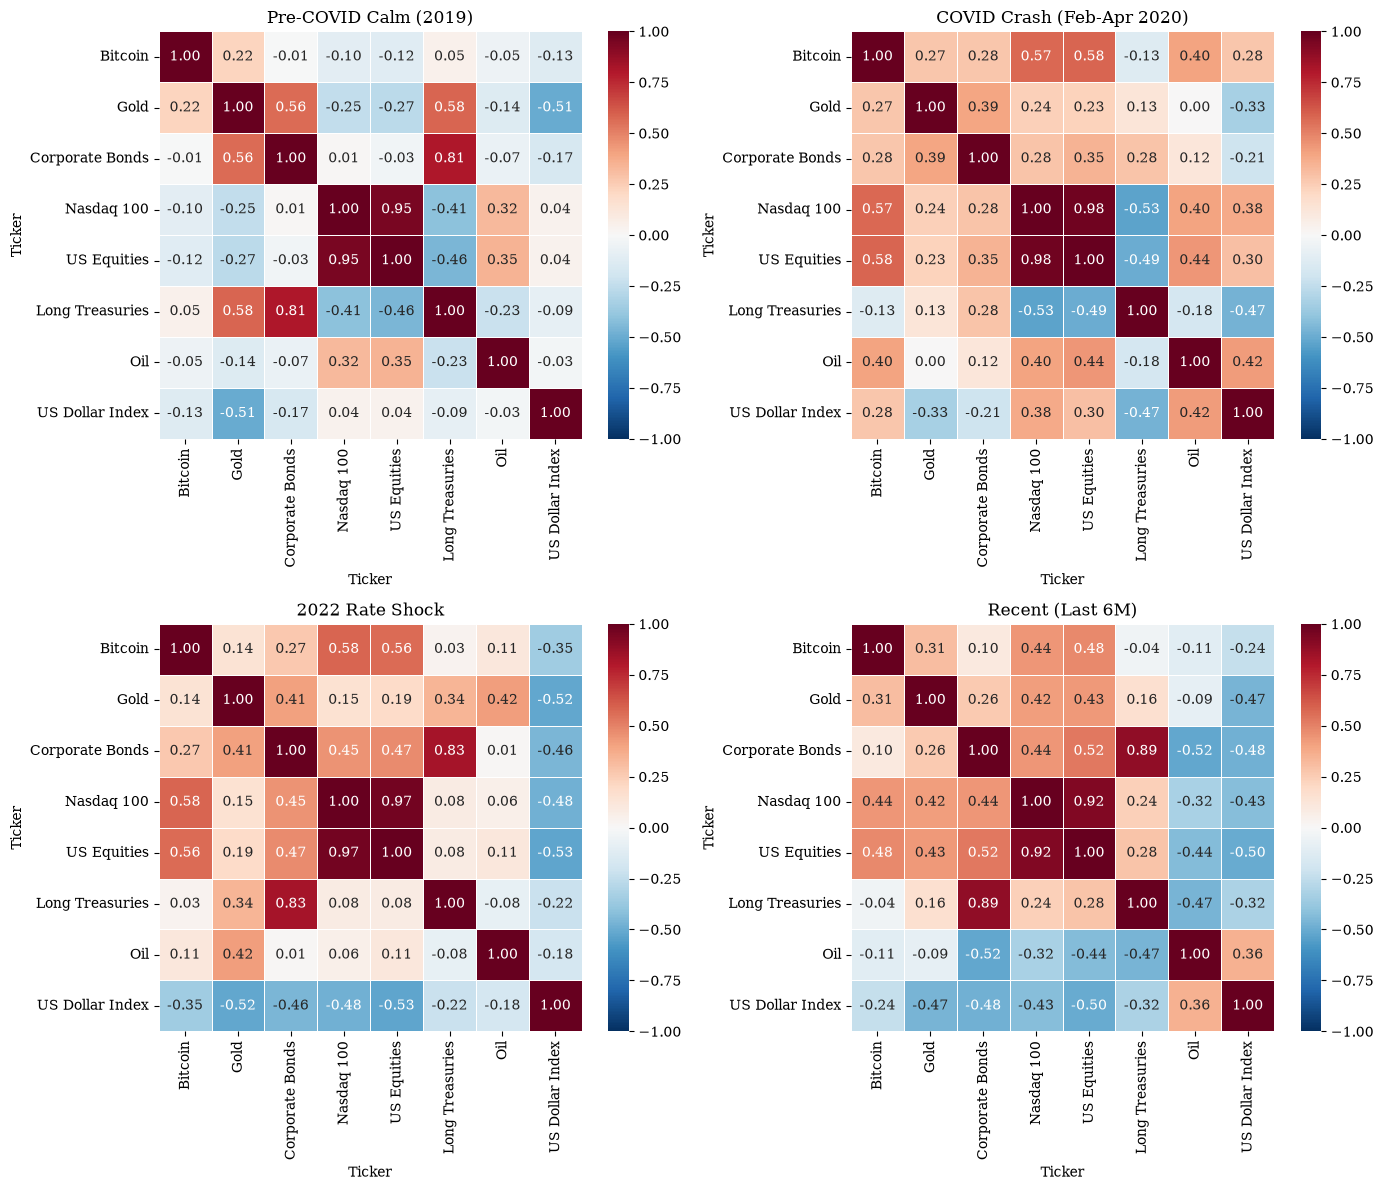

In [7]:
plot_period_comparison(snapshots, ticker_labels=TICKERS)

Saved rolling correlation plot to /Users/paulgrajzl/Documents/Quant-Projects/correlation-regime-shift/output/rolling_corr_SPY_vs_TLT.png


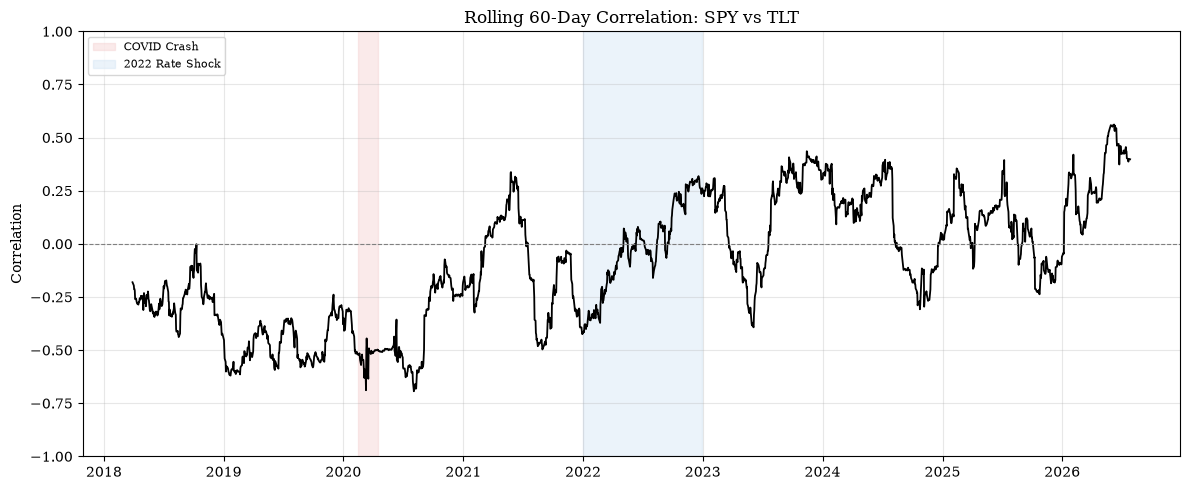

In [8]:
spy_tlt_corr = compute_rolling_correlation(returns, "SPY", "TLT", window=60)

highlight = {
    "COVID Crash": ("2020-02-15", "2020-04-15"),
    "2022 Rate Shock": ("2022-01-01", "2022-12-31"),
}

plot_rolling_correlation_pair(spy_tlt_corr, "SPY vs TLT", highlight_periods=highlight)

Saved rolling correlation plot to /Users/paulgrajzl/Documents/Quant-Projects/correlation-regime-shift/output/rolling_corr_BTC-USD_vs_QQQ.png


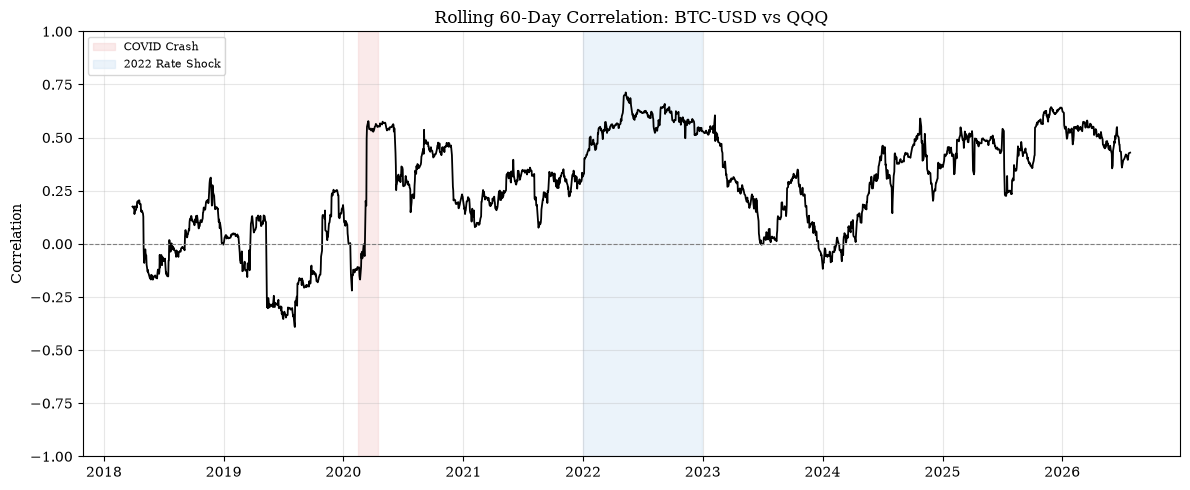

In [9]:
btc_qqq_corr = compute_rolling_correlation(returns, "BTC-USD", "QQQ", window=60)
plot_rolling_correlation_pair(btc_qqq_corr, "BTC-USD vs QQQ", highlight_periods=highlight)

Saved rolling correlation plot to /Users/paulgrajzl/Documents/Quant-Projects/correlation-regime-shift/output/rolling_corr_GLD_vs_UUP.png


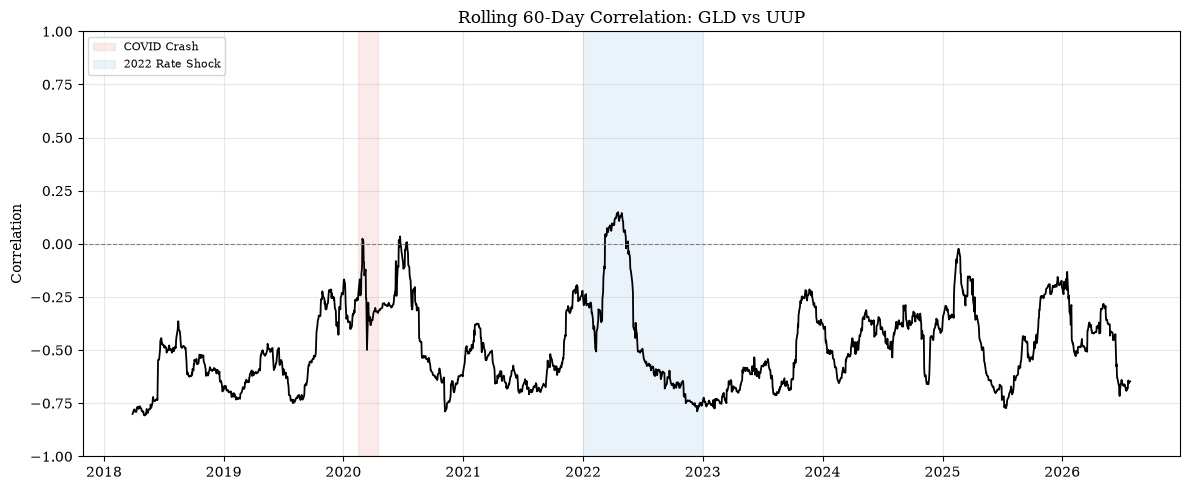

In [10]:
gld_uup_corr = compute_rolling_correlation(returns, "GLD", "UUP", window=60)
plot_rolling_correlation_pair(gld_uup_corr, "GLD vs UUP", highlight_periods=highlight)

In [11]:
from src.visualize import build_pair_correlation_dashboard

build_pair_correlation_dashboard(returns, ticker_labels=TICKERS, window=60)

Output()

In [ ]:
from src.visualize import build_interactive_heatmap_dashboard

build_interactive_heatmap_dashboard(returns, ticker_labels=TICKERS)

Output()